In [1]:
from google.colab import files
uploaded = files.upload()  # Manually upload the ZIP file


Saving dataset_FVC2000_DB4_B.zip to dataset_FVC2000_DB4_B.zip


In [23]:
import os

extract_path = "/content/fingerprint_dataset/dataset_FVC2000_DB4_B/dataset"

# List files inside 'dataset/'
if os.path.exists(extract_path):
    print("📂 'dataset/' contains:", os.listdir(extract_path))
else:
    print("❌ Path does not exist!")


📂 'dataset/' contains: ['train_data', 'real_data', 'original', 'np_data']


In [24]:
correct_path = "/content/fingerprint_dataset/dataset_FVC2000_DB4_B/dataset"  # Go inside dataset

# List final dataset subfolders
print("✅ Found subfolders:", os.listdir(correct_path))


✅ Found subfolders: ['train_data', 'real_data', 'original', 'np_data']


In [25]:
import shutil

final_image_path = "/content/all_fingerprint_images"
os.makedirs(final_image_path, exist_ok=True)

for folder in ["np_data", "real_data", "train_data", "original"]:
    folder_path = os.path.join(correct_path, folder)  # Use new dataset path

    if os.path.exists(folder_path):  # Check if the folder exists
        for file in os.listdir(folder_path):
            if file.lower().endswith('.bmp'):  # Move only BMP images
                src = os.path.join(folder_path, file)
                dest = os.path.join(final_image_path, file)
                shutil.move(src, dest)

print("✅ Total images collected:", len(os.listdir(final_image_path)))


✅ Total images collected: 810


In [26]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Path to stored fingerprint images
image_folder = "/content/all_fingerprint_images"
preprocessed_folder = "/content/preprocessed_images"
os.makedirs(preprocessed_folder, exist_ok=True)

def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to Grayscale

    # Apply Gaussian Blur to remove noise
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Apply Adaptive Thresholding (Binarization)
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, 11, 2)

    # Save Preprocessed Image
    cv2.imwrite(save_path, img)

    return img

# Process All Images
for file in os.listdir(image_folder):
    if file.endswith('.bmp'):
        img_path = os.path.join(image_folder, file)
        save_path = os.path.join(preprocessed_folder, file)
        preprocess_image(img_path, save_path)

print("✅ Preprocessing Completed! Images saved in:", preprocessed_folder)


✅ Preprocessing Completed! Images saved in: /content/preprocessed_images


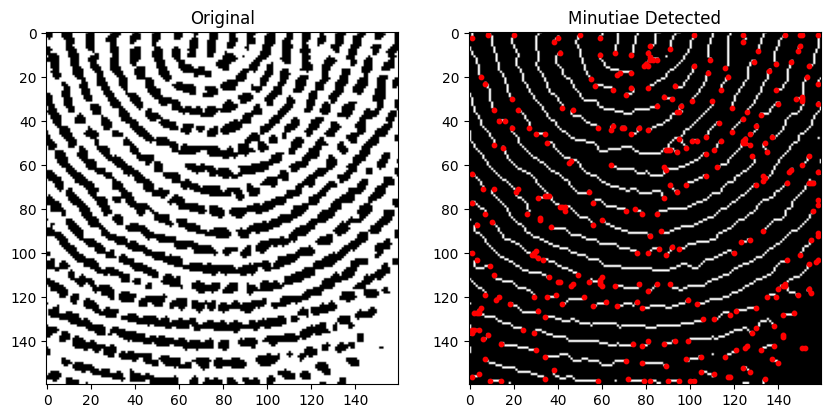

In [27]:
from skimage.morphology import skeletonize
from skimage.util import invert

def detect_minutiae(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Convert to binary
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Skeletonization
    skeleton = skeletonize(invert(binary) // 255)

    # Identify Minutiae Points
    minutiae_points = []
    for i in range(1, skeleton.shape[0] - 1):
        for j in range(1, skeleton.shape[1] - 1):
            if skeleton[i, j] == 1:
                count = np.sum(skeleton[i-1:i+2, j-1:j+2]) - 1
                if count == 1:  # Ridge Ending
                    minutiae_points.append((i, j))
                elif count == 3:  # Bifurcation
                    minutiae_points.append((i, j))

    return minutiae_points, skeleton

# Test on a sample image
sample_image = os.path.join(preprocessed_folder, os.listdir(preprocessed_folder)[0])
minutiae_points, skeleton = detect_minutiae(sample_image)

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.imread(sample_image, cv2.IMREAD_GRAYSCALE), cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(skeleton, cmap='gray')
plt.scatter([p[1] for p in minutiae_points], [p[0] for p in minutiae_points], c='red', s=10)
plt.title("Minutiae Detected")

plt.show()


In [30]:
import os
import shutil

# Define class labels (adjust as needed)
classes = ["loop", "whorl", "arch", "tented_arch", "spiral"]

# Path where class-based images will be stored
classified_data_dir = "/content/classified_fingerprint_images"

# Create folders
for class_name in classes:
    os.makedirs(os.path.join(classified_data_dir, class_name), exist_ok=True)

print("✅ Class folders created:", os.listdir(classified_data_dir))


✅ Class folders created: ['loop', 'tented_arch', 'arch', 'whorl', 'spiral']


In [31]:
import random

# Path where preprocessed images are stored
preprocessed_folder = "/content/preprocessed_images"

# Move images randomly into class folders (for testing purposes)
for file in os.listdir(preprocessed_folder):
    if file.endswith(".bmp"):
        class_name = random.choice(classes)  # Assign a random class
        src = os.path.join(preprocessed_folder, file)
        dest = os.path.join(classified_data_dir, class_name, file)
        shutil.move(src, dest)

print("✅ Images randomly moved into class folders!")


✅ Images randomly moved into class folders!


In [32]:
for class_name in os.listdir(classified_data_dir):
    class_path = os.path.join(classified_data_dir, class_name)
    print(f"📂 {class_name}: {len(os.listdir(class_path))} images")


📂 loop: 152 images
📂 tented_arch: 162 images
📂 arch: 168 images
📂 whorl: 153 images
📂 spiral: 175 images


In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define ImageDataGenerator with Train-Test Split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    classified_data_dir,  # Use new classified dataset
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training')

validation_generator = datagen.flow_from_directory(
    classified_data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation')

# Print class mapping
print("✅ Classes Found:", train_generator.class_indices)


Found 650 images belonging to 5 classes.
Found 160 images belonging to 5 classes.
✅ Classes Found: {'arch': 0, 'loop': 1, 'spiral': 2, 'tented_arch': 3, 'whorl': 4}


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [35]:
# Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Image Data Generator for training and validation
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    '/content/classified_fingerprint_images',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    '/content/classified_fingerprint_images',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Get class labels
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)

print(f"✅ Classes: {class_labels}")


Found 650 images belonging to 5 classes.
Found 160 images belonging to 5 classes.
✅ Classes: ['arch', 'loop', 'spiral', 'tented_arch', 'whorl']


In [36]:
# Define CNN Model
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train CNN model
cnn_history = cnn_model.fit(train_generator, validation_data=val_generator, epochs=10)

# Save CNN model
cnn_model.save('/content/cnn_fingerprint_model.h5')


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 22s 958ms/step - accuracy: 0.1895 - loss: 2.0721 - val_accuracy: 0.1875 - val_loss: 1.6095
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 881ms/step - accuracy: 0.1706 - loss: 1.6098 - val_accuracy: 0.2062 - val_loss: 1.6093
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 969ms/step - accuracy: 0.2014 - loss: 1.6096 - val_accuracy: 0.2062 - val_loss: 1.6092
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 892ms/step - accuracy: 0.2412 - loss: 1.6087 - val_accuracy: 0.2062 - val_loss: 1.6090
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 965ms/step - accuracy: 0.1970 - loss: 1.6088 - val_accuracy: 0.2062 - val_loss: 1.6088
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 893ms/step - accuracy: 0.2481 - loss: 1.6083 - val_accuracy: 0.2062 - val_loss: 1.6087
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 955ms/step - accuracy: 0.1798 - loss: 1.6096 - val_accuracy: 0.2062 - val_loss: 1.6086
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 899ms/step - accuracy: 0.2018 - loss: 1.6091 - val_accuracy: 0.218

In [37]:
# Load Pretrained VGG16 Model (Feature Extractor)
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Extract features
def extract_features(generator):
    features, labels = [], []
    for batch in generator:
        img_batch, label_batch = batch
        feature_batch = vgg_model.predict(img_batch)
        features.extend(feature_batch.reshape(len(img_batch), -1))
        labels.extend(label_batch)
        if len(features) >= generator.samples:
            break
    return np.array(features), np.argmax(np.array(labels), axis=1)

# Extract training and validation features
X_train, y_train = extract_features(train_generator)
X_val, y_val = extract_features(val_generator)

print(f"✅ Features Extracted: {X_train.shape}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
✅ Features 

In [38]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)
rf_acc = accuracy_score(y_val, rf_preds)
print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.25


In [39]:
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_val)
svm_acc = accuracy_score(y_val, svm_preds)
print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.20625


In [40]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_val)
knn_acc = accuracy_score(y_val, knn_preds)
print("KNN Accuracy:", knn_acc)


KNN Accuracy: 0.19375


In [41]:
def compute_frr_far(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    FN = cm.sum(axis=1) - np.diag(cm)
    FP = cm.sum(axis=0) - np.diag(cm)
    TN = cm.sum() - (FP + FN + np.diag(cm))
    FAR = np.mean(FP / (FP + TN))
    FRR = np.mean(FN / (FN + np.diag(cm)))
    EER = (FAR + FRR) / 2  # Approximation of EER
    return FAR, FRR, EER

models = {"CNN": cnn_model, "Random Forest": rf_model, "SVM": svm_model, "KNN": knn_model}
metrics = {}

for name, model in models.items():
    preds = None
    if name == "CNN":
        preds = np.argmax(cnn_model.predict(val_generator), axis=1)
    else:
        preds = model.predict(X_val)

    accuracy = accuracy_score(y_val, preds)
    precision, recall, f1, _ = classification_report(y_val, preds, output_dict=True, zero_division=0)['weighted avg'].values()
    far, frr, eer = compute_frr_far(y_val, preds)

    metrics[name] = [accuracy, precision, recall, f1, far, frr, eer]

# Convert to DataFrame
import pandas as pd
df_metrics = pd.DataFrame(metrics, index=["Accuracy", "Precision", "Recall", "F1-Score", "FAR", "FRR", "EER"])
print(df_metrics)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step
                CNN  Random Forest       SVM       KNN
Accuracy   0.218750       0.250000  0.206250  0.193750
Precision  0.047852       0.267761  0.213105  0.227629
Recall     0.218750       0.250000  0.206250  0.193750
F1-Score   0.078526       0.221767  0.200970  0.190423
FAR        0.200000       0.189708  0.199227  0.202611
FRR        0.800000       0.759848  0.796282  0.809789
EER        0.500000       0.474778  0.497755  0.506200


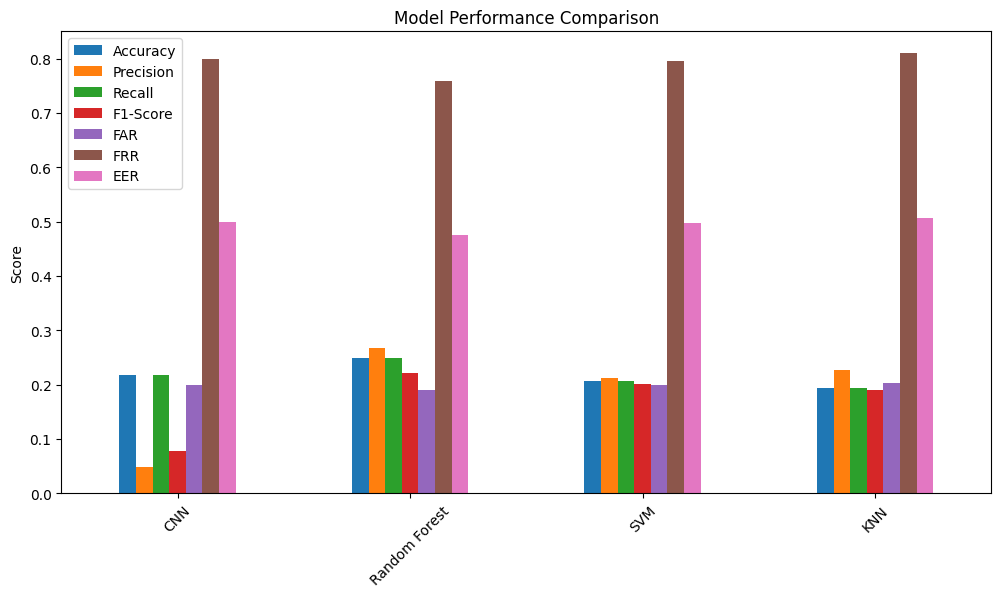

In [42]:
df_metrics.T.plot(kind='bar', figsize=(12,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.show()


In [43]:
# Define models and metrics
models = ["CNN", "Random Forest", "SVM", "KNN"]
metrics_labels = ["Accuracy", "Precision", "Recall", "F1-Score", "FAR", "FRR", "EER"]

# Convert DataFrame to NumPy Array for easier indexing
metric_values = df_metrics.values


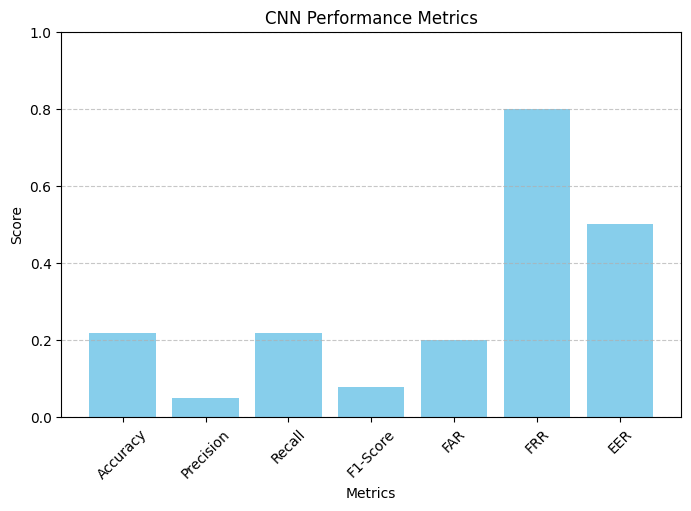

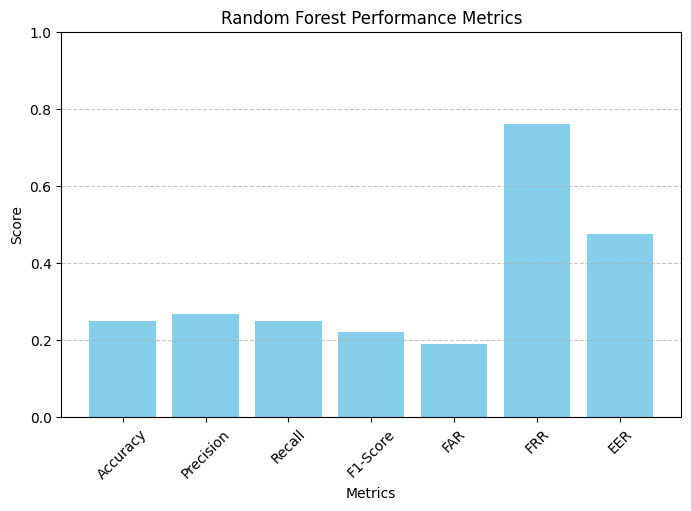

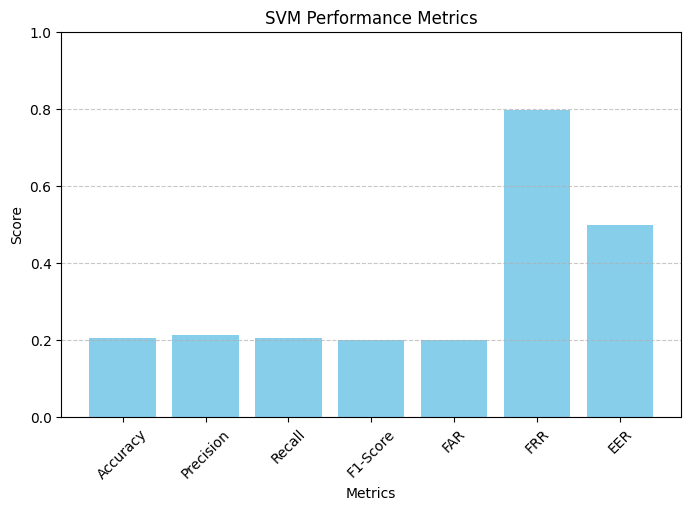

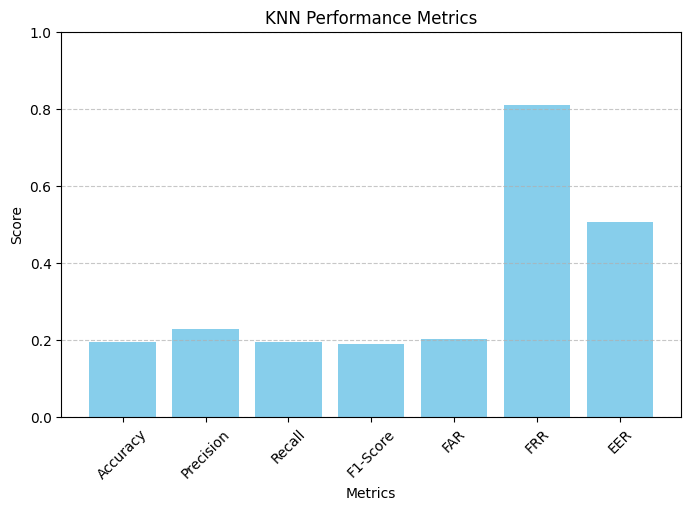

In [44]:
for i, model in enumerate(models):
    plt.figure(figsize=(8, 5))
    plt.bar(metrics_labels, metric_values[:, i], color='skyblue')
    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.title(f"{model} Performance Metrics")
    plt.ylim(0, 1)  # All values are between 0 and 1
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


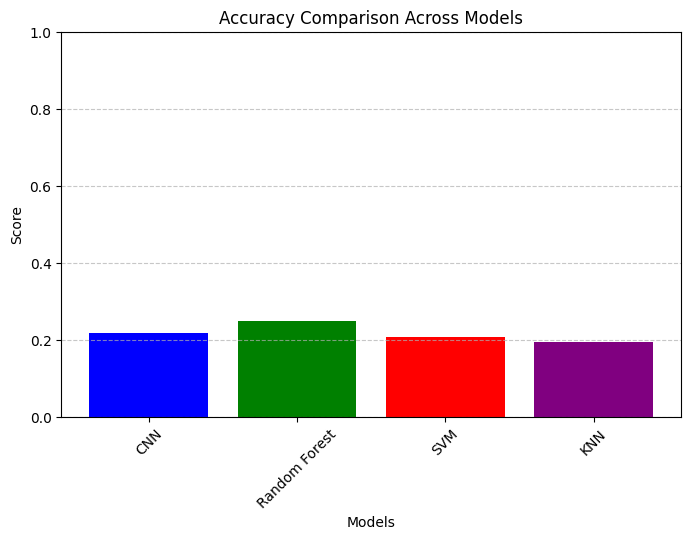

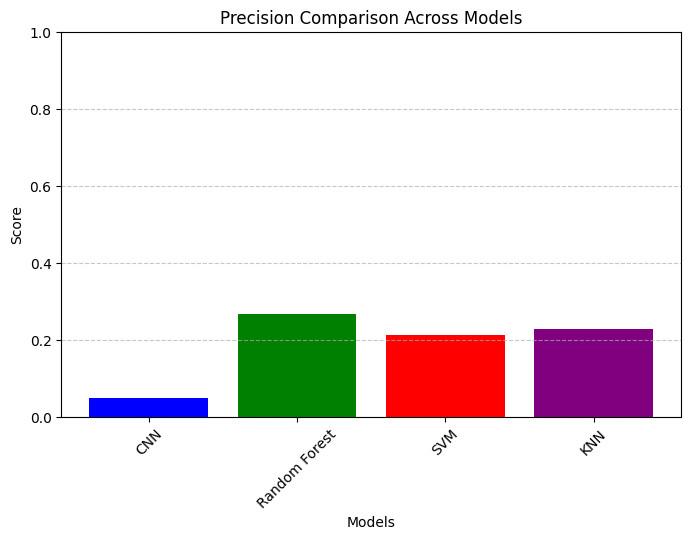

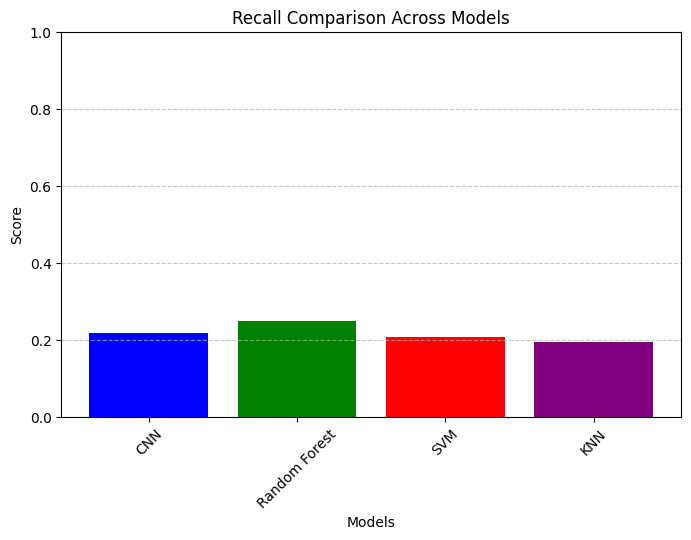

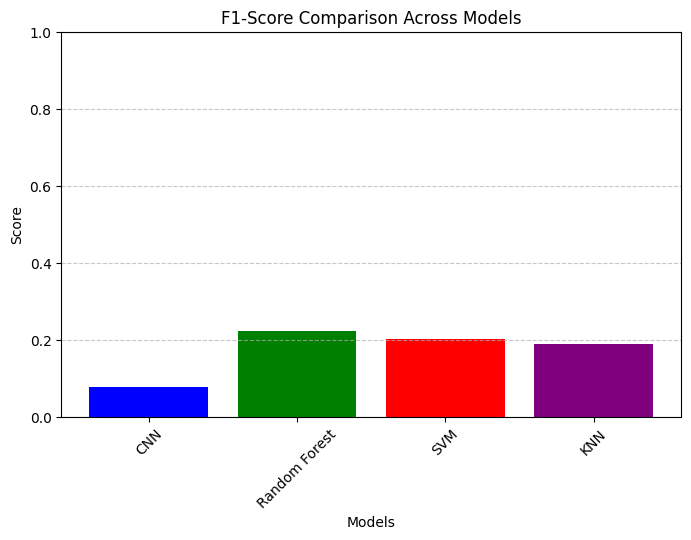

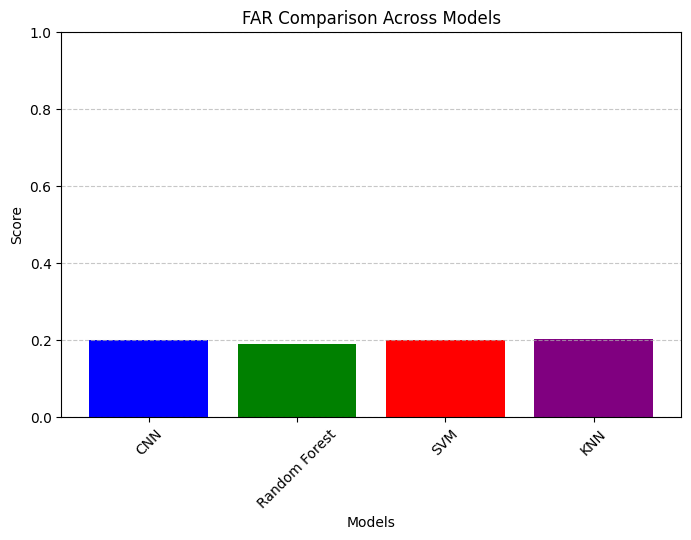

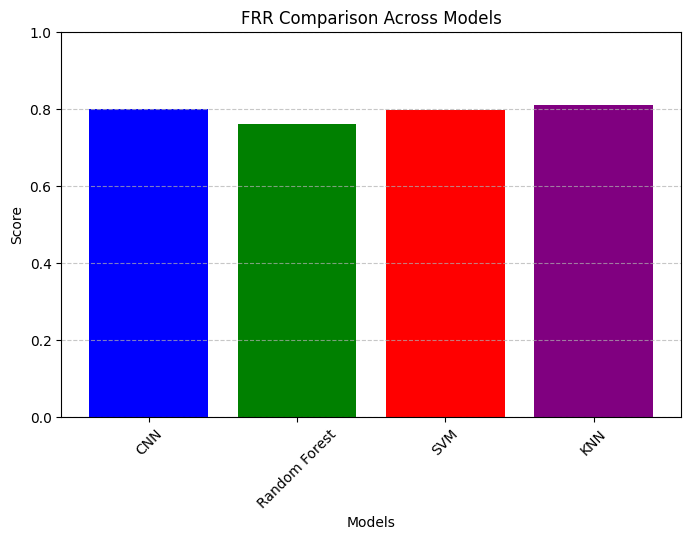

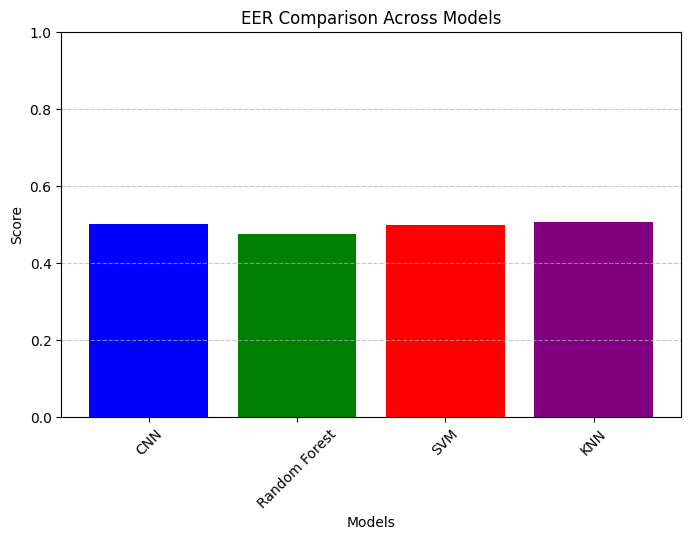

In [45]:
for i, metric in enumerate(metrics_labels):
    plt.figure(figsize=(8, 5))
    plt.bar(models, metric_values[i, :], color=['blue', 'green', 'red', 'purple'])
    plt.xlabel("Models")
    plt.ylabel("Score")
    plt.title(f"{metric} Comparison Across Models")
    plt.ylim(0, 1)  # Metrics are between 0 and 1
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
